In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter, fig_loops
from utils.pd_utils import sort_cycle
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max, distribution_split

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max, fig_bottleneck_median_scale, get_life_geq_scale, get_life_geq_metrics

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.total_variation import total_variation_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


<h4 style="background-color: yellow; padding: 5px;">

compare 4 std and 2 90 percentile

</h4>

In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# load threshoods...

In [ ]:
threshold_conditions = [[],[]]

for full_dist in full_dists:
    bdists = [] 
    for i, dataset in enumerate(sex_data):
        bdist = load_dict(os.path.join(get_path("data"),f"{dataset}/bottleneck_dists_split_quarter_{full_dist}.pkl"))["bottleneck"]
        bdists.append(bdist)
    bdists = np.array(bdists)
    bdists_flat = bdists[np.triu_indices_from(bdists, k=1)]    
    # print(len(bdists_flat))
    # print(np.percentile(bdists_flat, 90))
    threshold_conditions[0].append(2 * np.percentile(bdists_flat, 90))
    threshold_conditions[1].append(4 * np.sqrt(1/(15**2)*np.sum(bdists_flat**2)))

# female

In [ ]:
def batch_print_female(j):
    sex_data =[f"yao_10x_female_orange_split_{i}" for i in range(5)]
    embds =[f"embd_10x_female_orange_split_{i}" for i in range(5)]
    all_res = load_multiple_res(datasets=sex_data[j], n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    enm =  np.load(os.path.join(root_path, f"embd_n_mask/embd_after_procrustes/{embds[j]}.npy"))
    fig_loops(all_res,  embd_n_mask =  enm, cell_group_name=sex_data[j], confidence = np.array(threshold_conditions), save = False)

Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_0 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


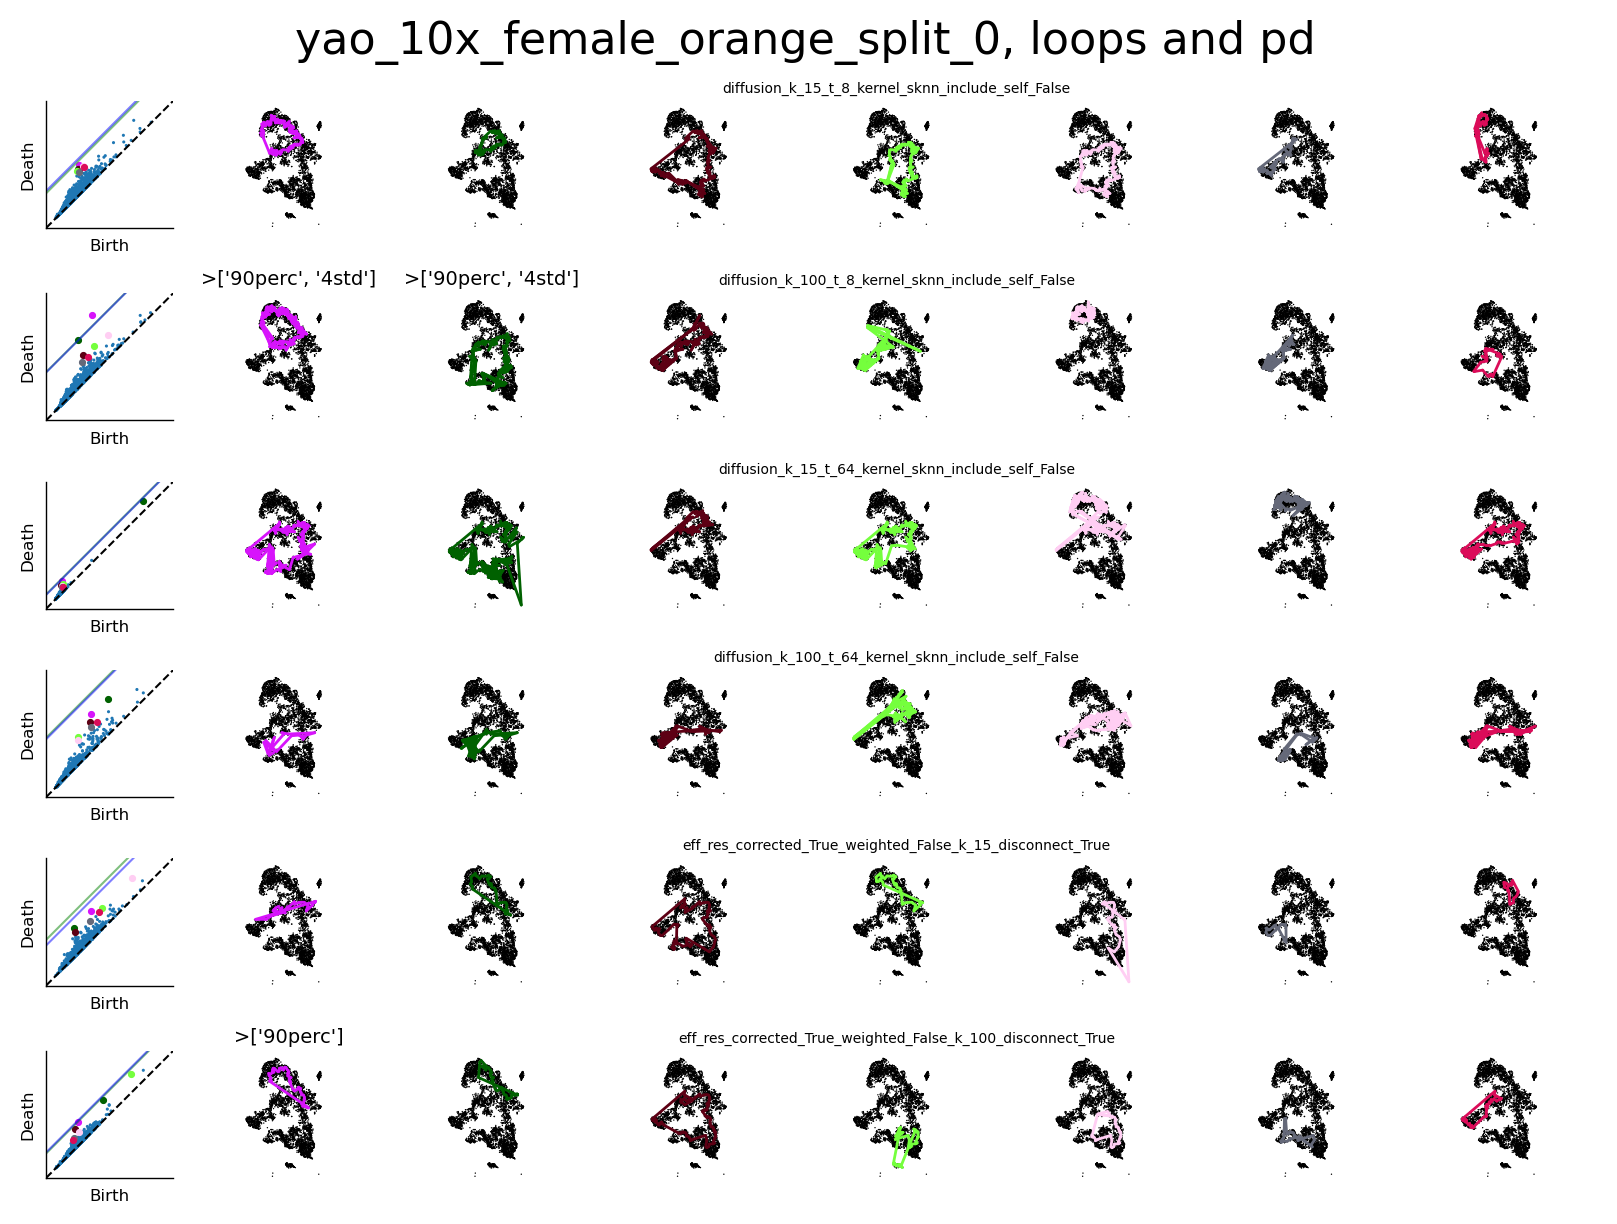

In [ ]:
batch_print_female(j = 0)

Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_1 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


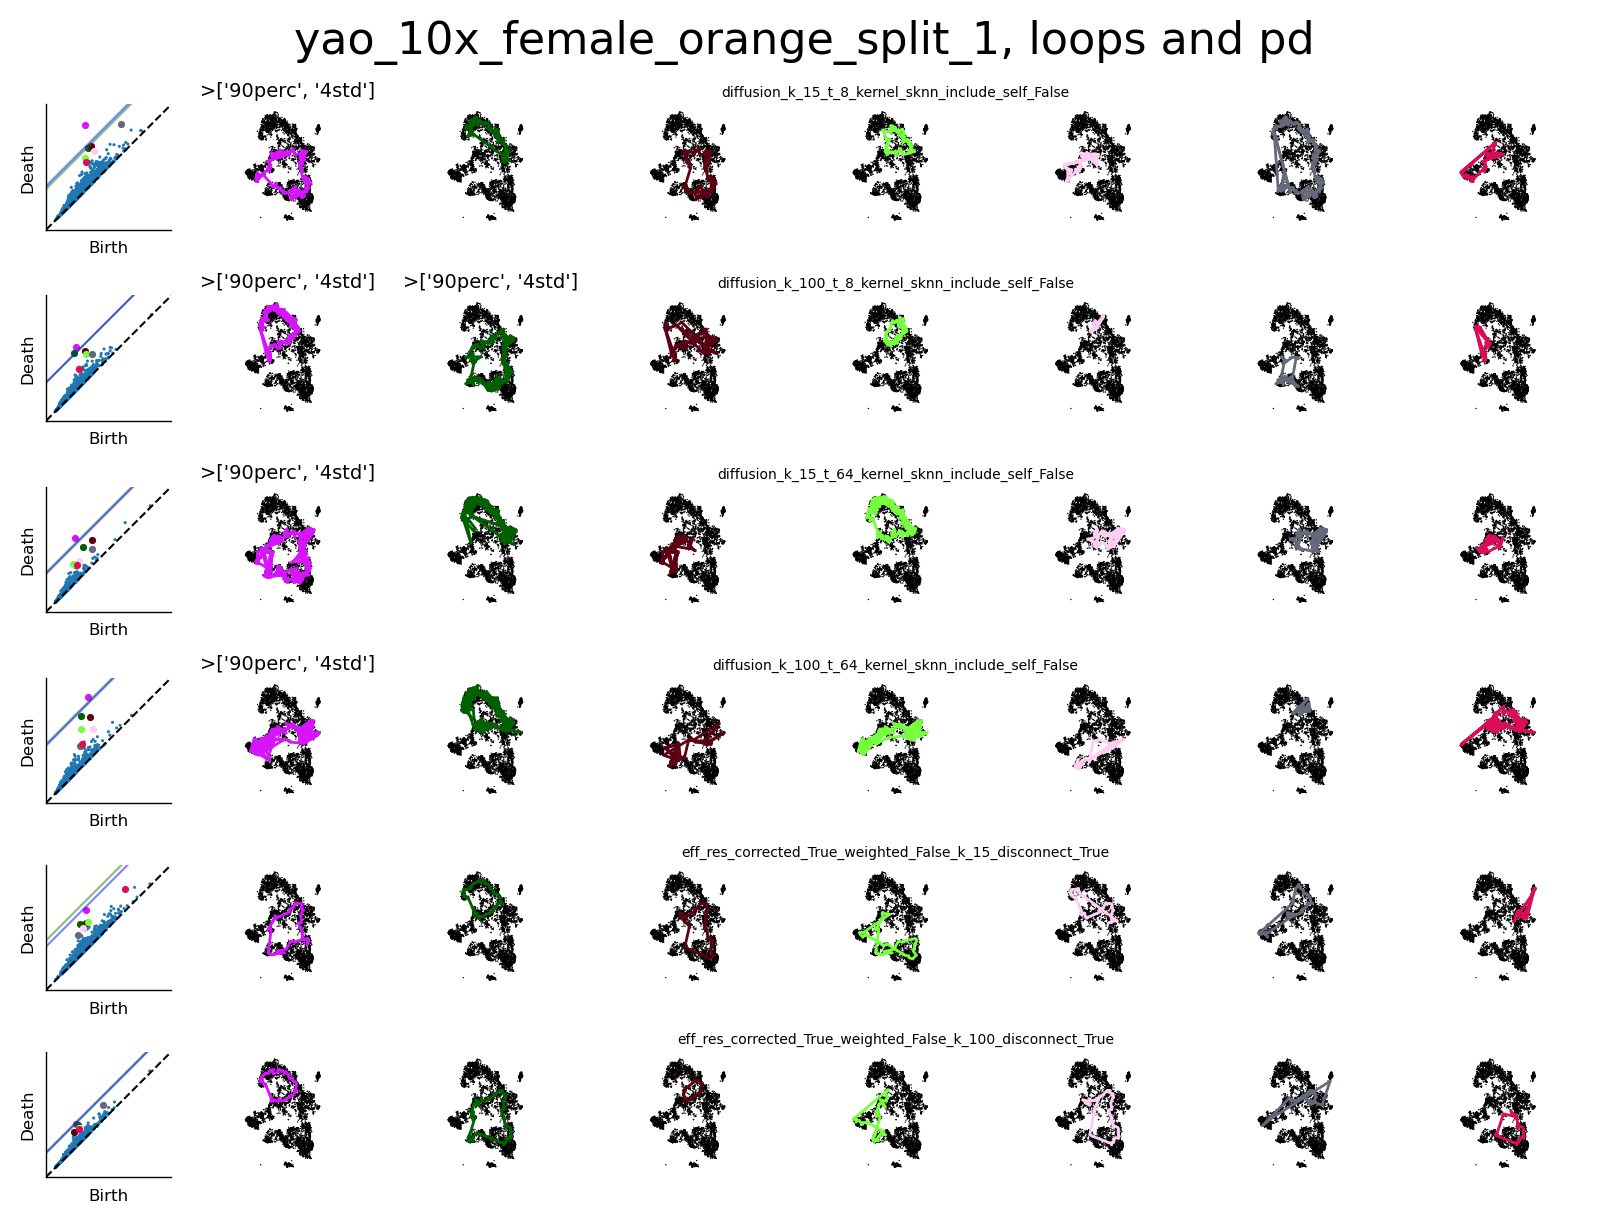

In [ ]:
batch_print_female(j = 1)

Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_2 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


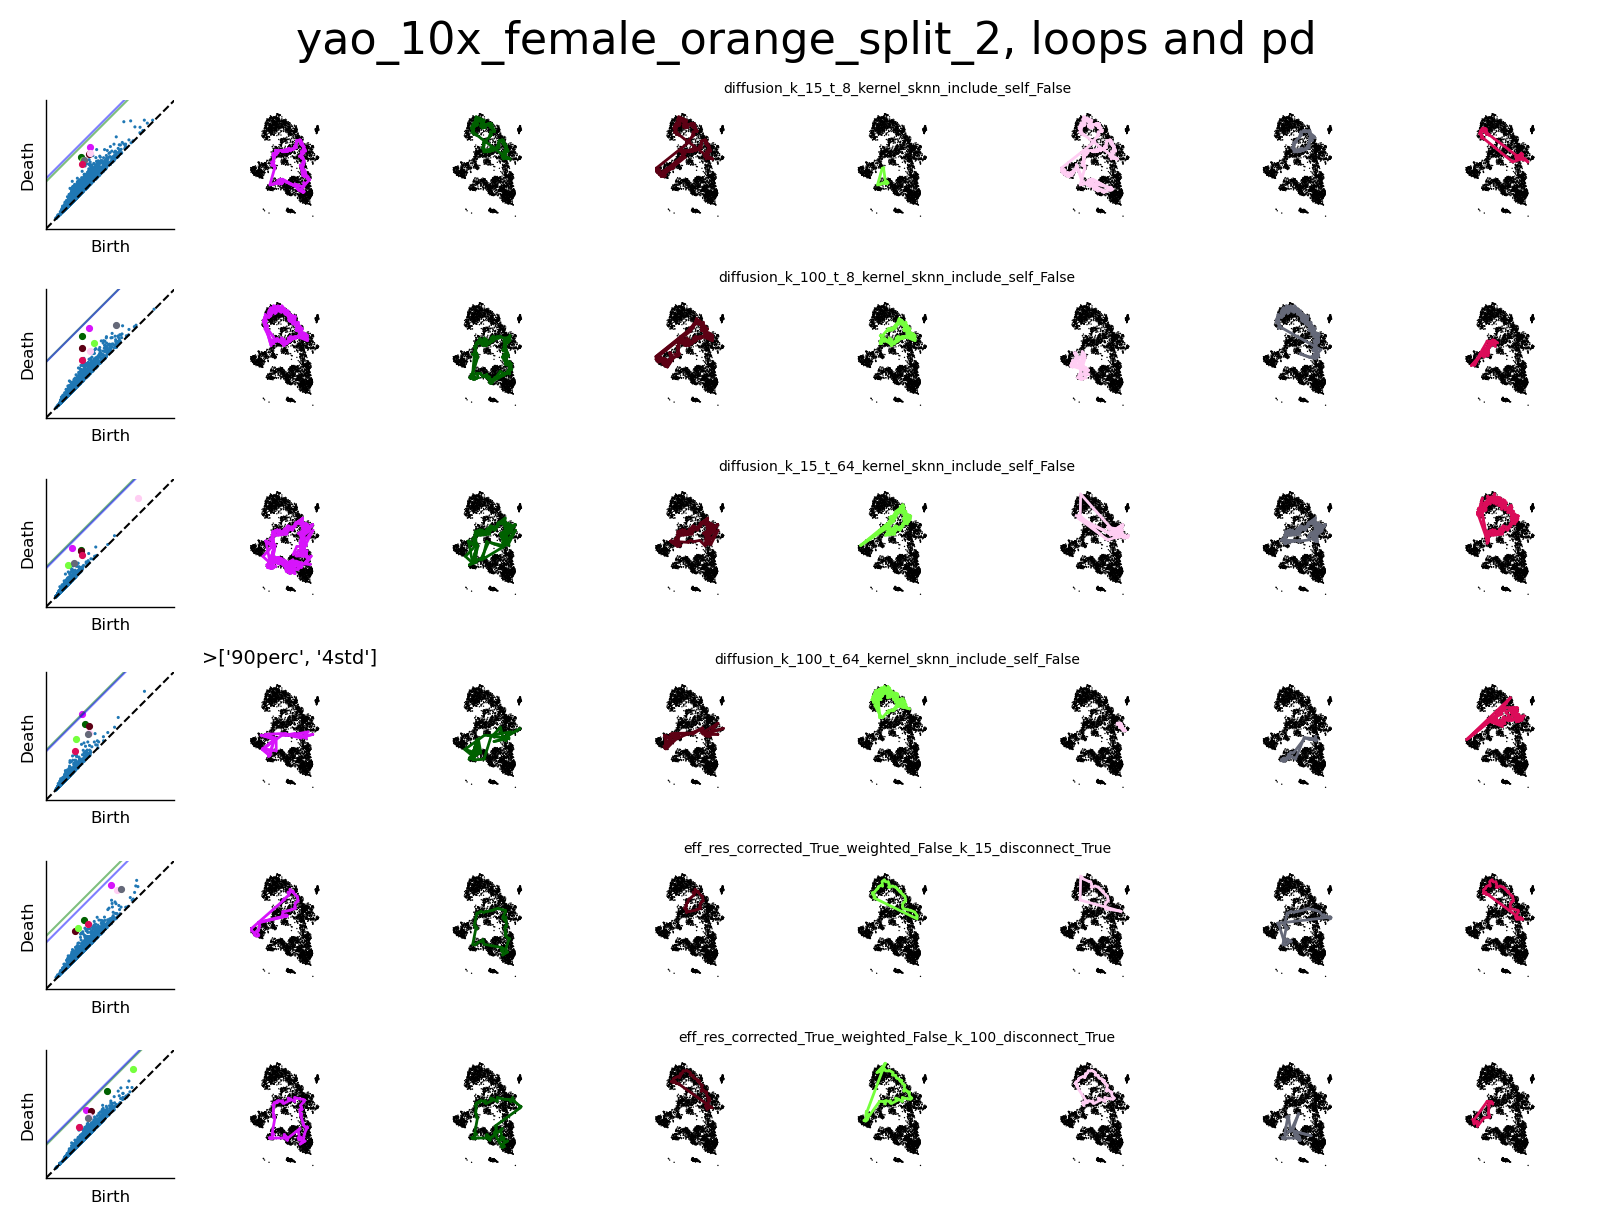

In [ ]:
batch_print_female(j = 2)

Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_3 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


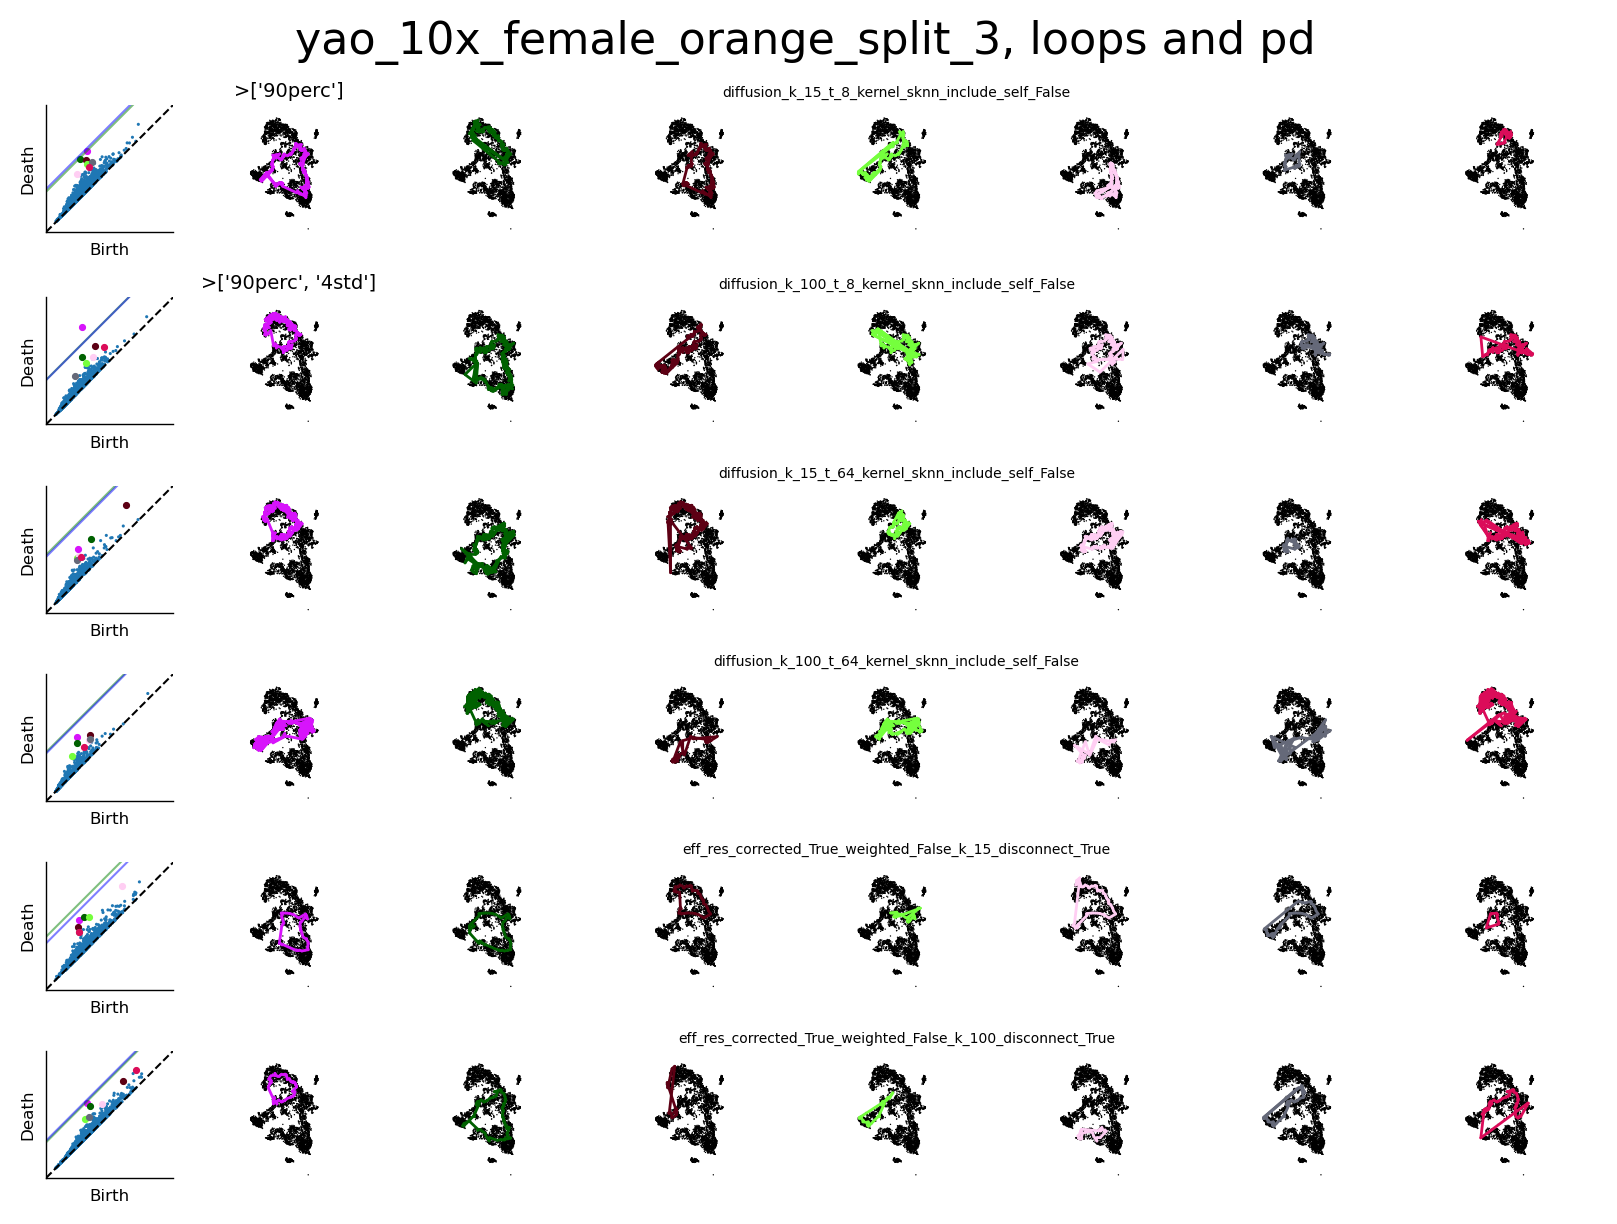

In [ ]:
batch_print_female(j = 3)

Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_split_4 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


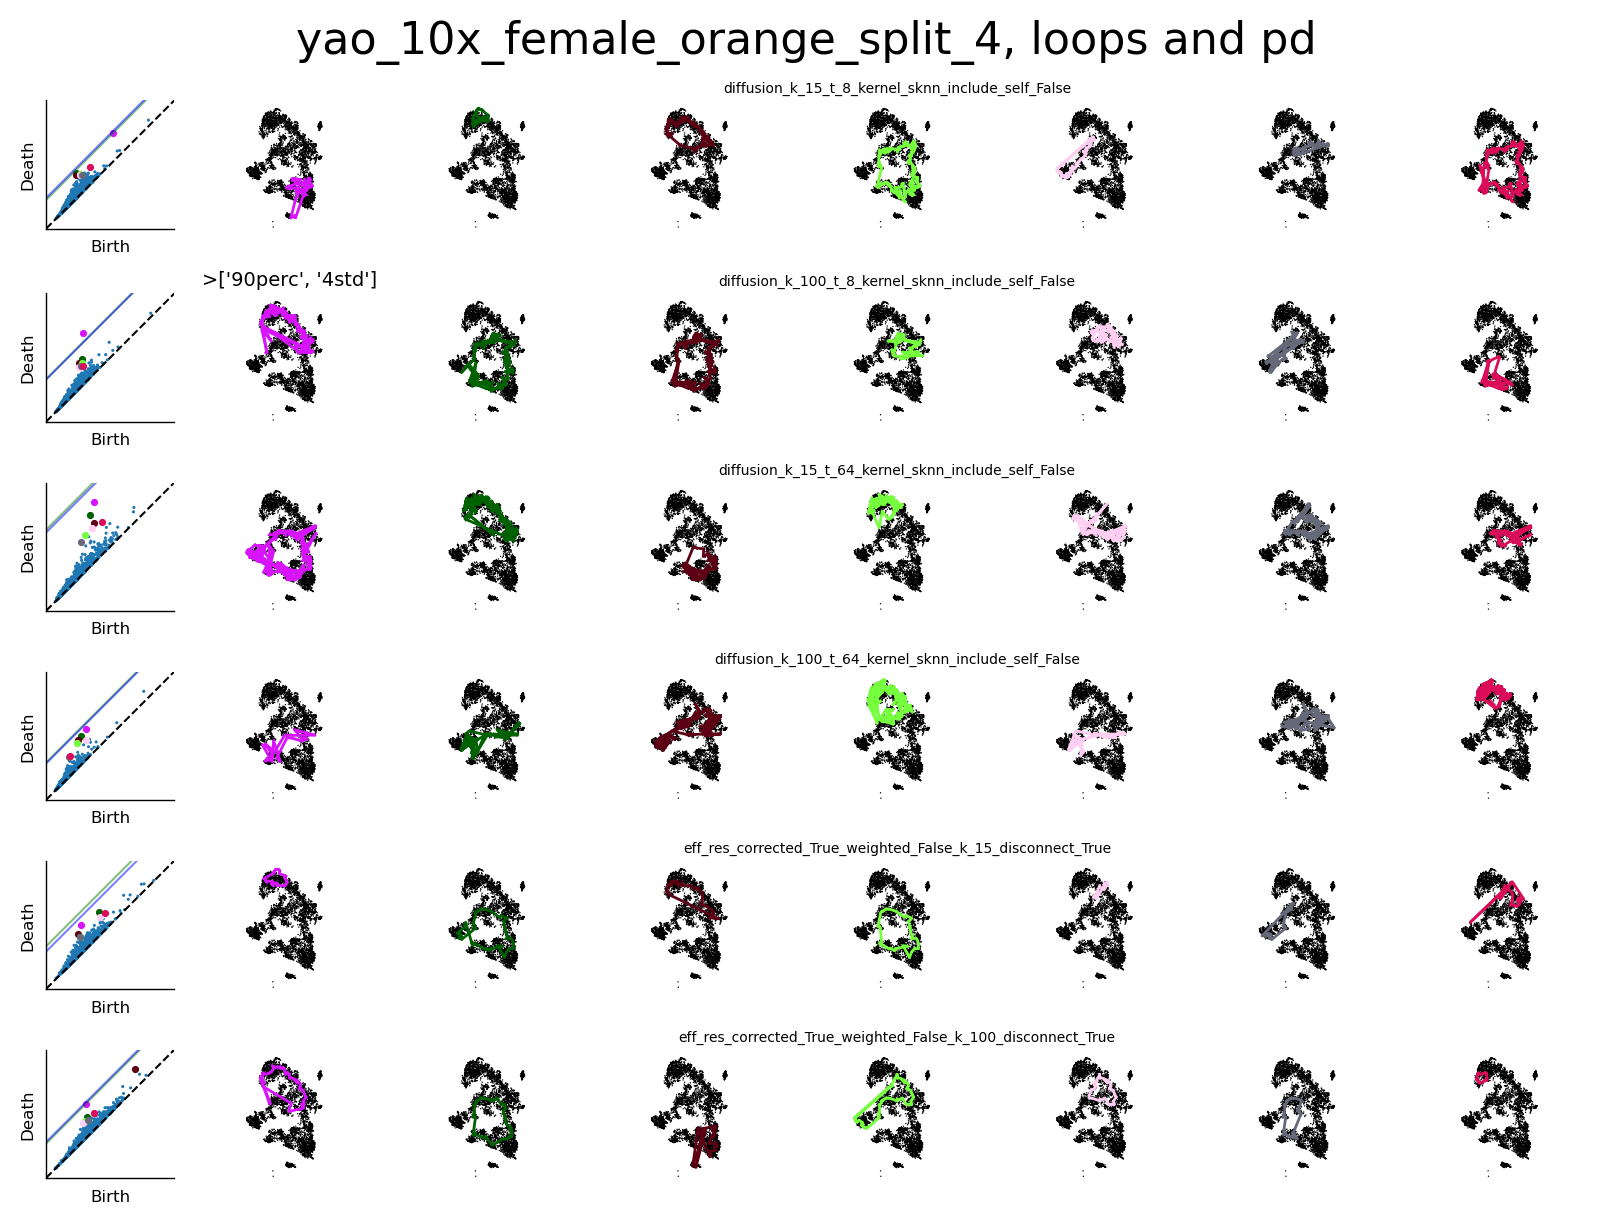

In [ ]:
batch_print_female(j = 4)

# male

In [ ]:
def batch_print_male(j):
    sex_data =[f"yao_10x_male_orange_split_{i}" for i in range(10)]
    embds =[f"embd_10x_male_orange_split_{i}" for i in range(10)]
    all_res = load_multiple_res(datasets=sex_data[j], n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    enm =  np.load(os.path.join(root_path, f"embd_n_mask/embd_after_procrustes/{embds[j]}.npy"))
    fig_loops(all_res,  embd_n_mask = enm, cell_group_name=sex_data[j], confidence = np.array(threshold_conditions), save = False)

Done with yao_10x_male_orange_split_0 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_0 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_0 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_0 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_0 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_0 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


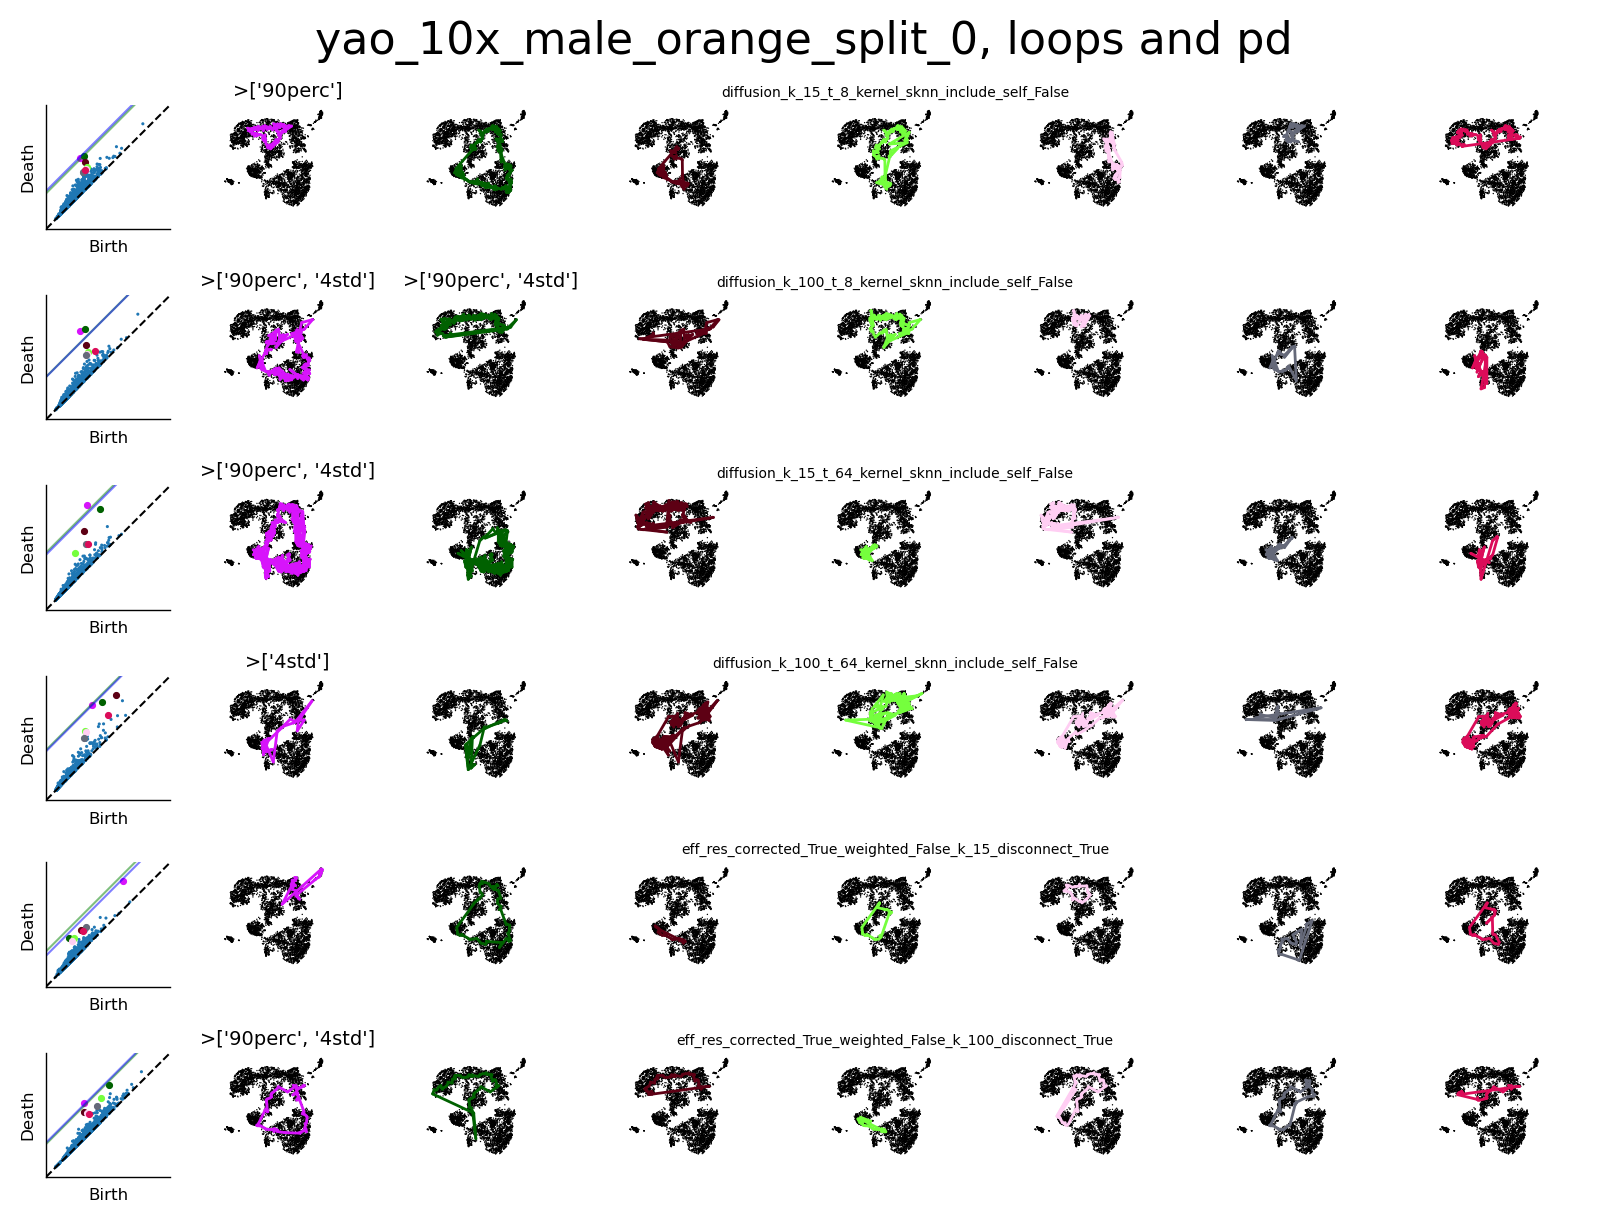

In [ ]:
batch_print_male(0)

Done with yao_10x_male_orange_split_1 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_1 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None


Done with yao_10x_male_orange_split_1 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_1 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_1 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_1 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


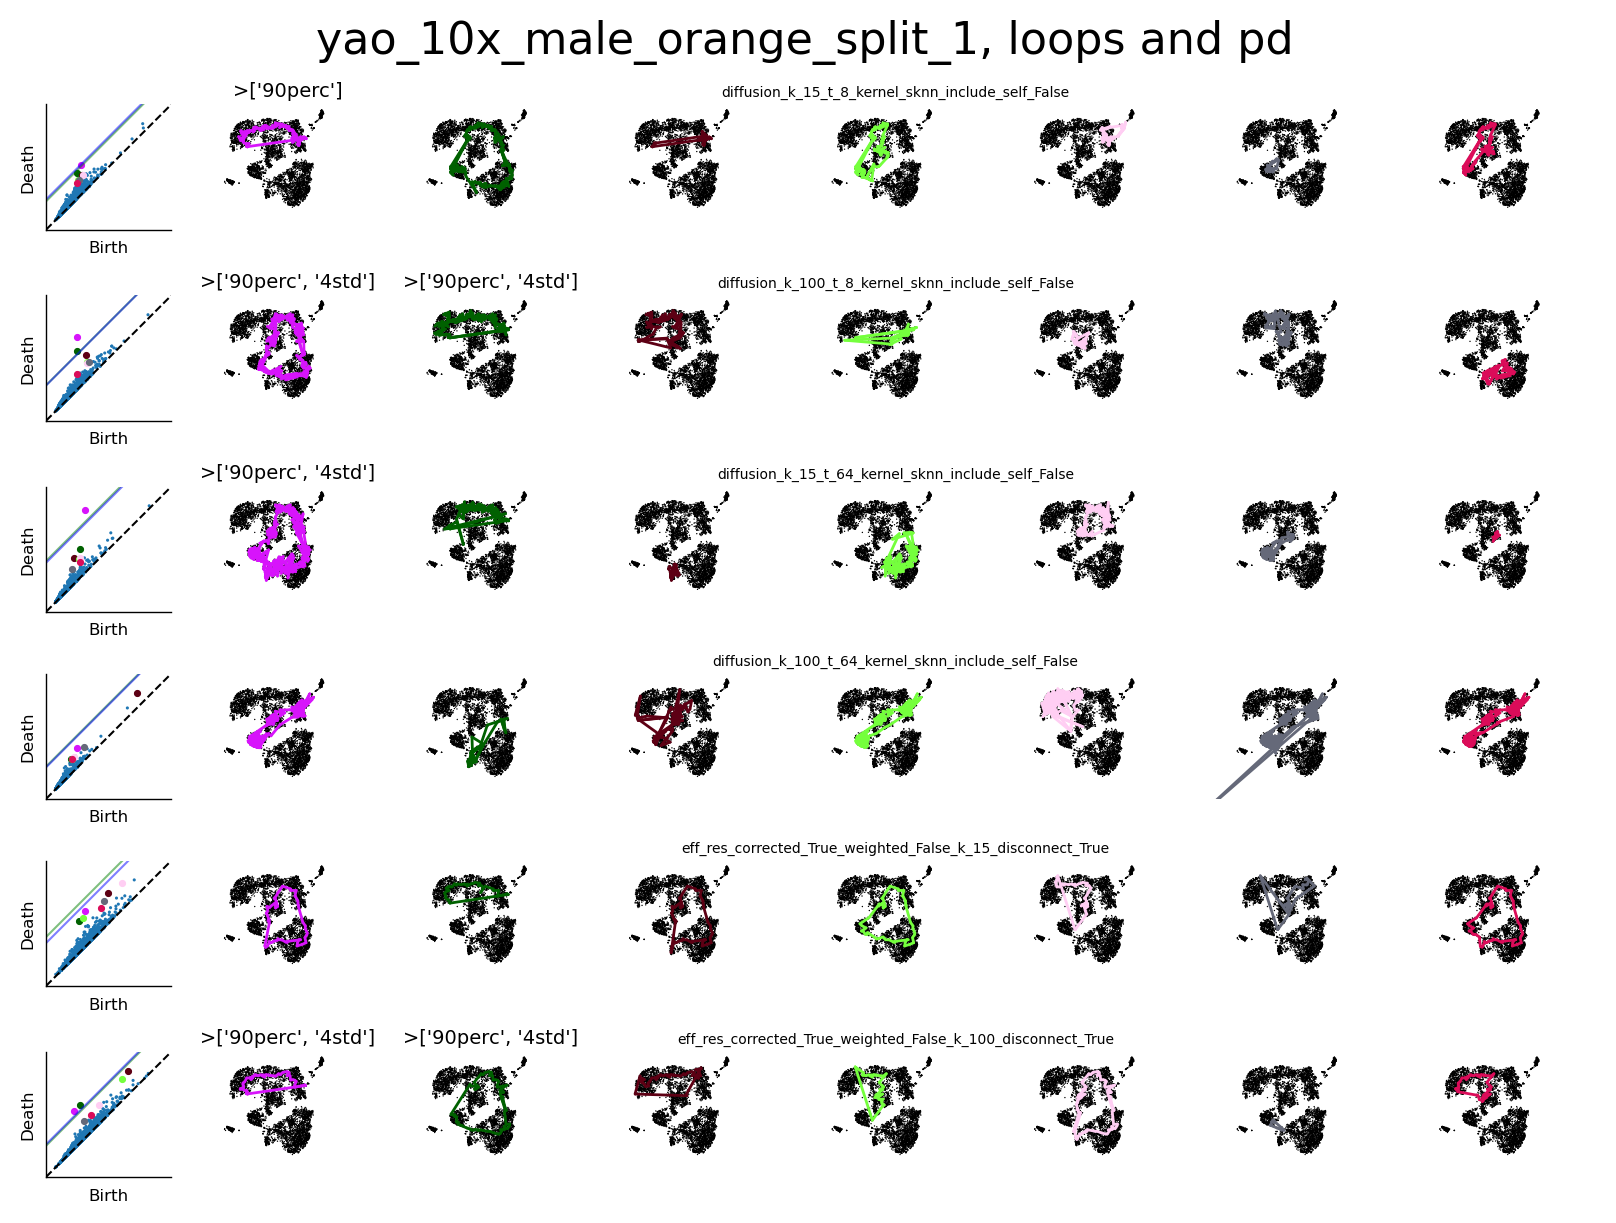

In [ ]:
batch_print_male(1)

Done with yao_10x_male_orange_split_2 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_2 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_2 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_2 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_2 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_2 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


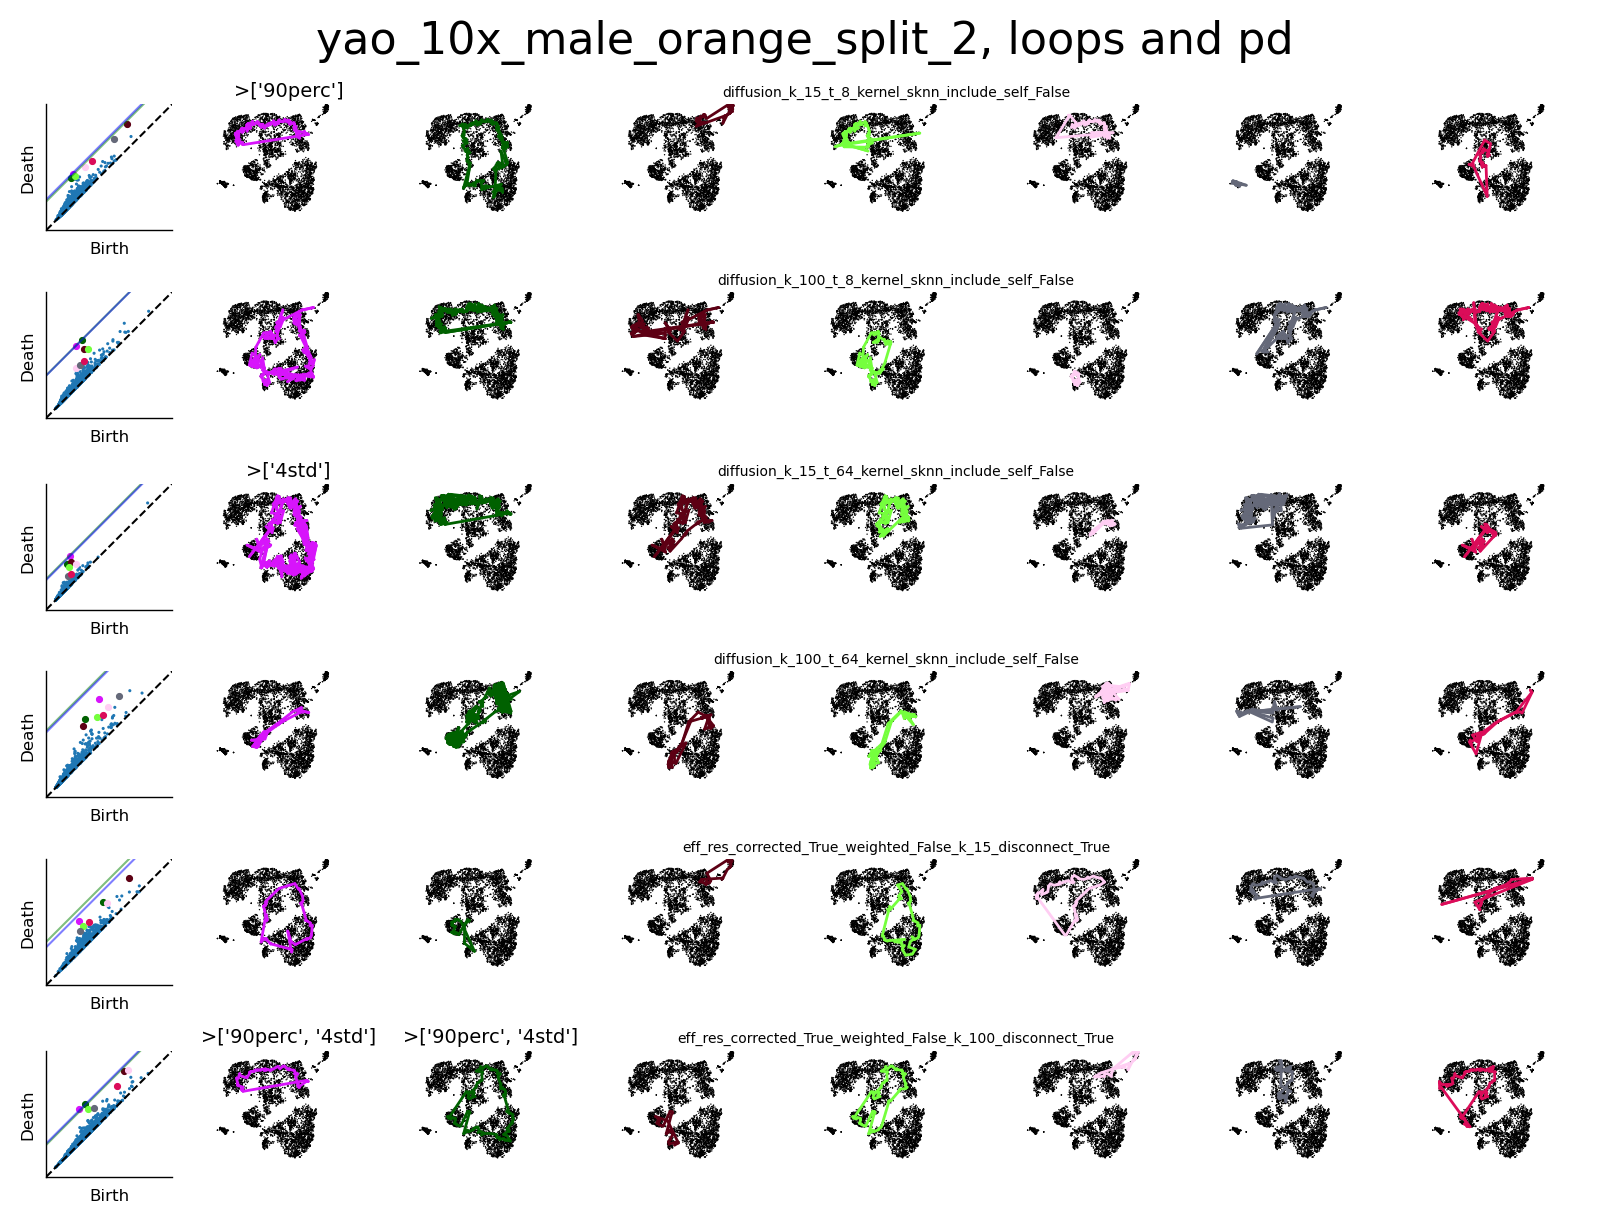

In [ ]:
batch_print_male(2)

Done with yao_10x_male_orange_split_3 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_3 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_3 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_3 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_3 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_split_3 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


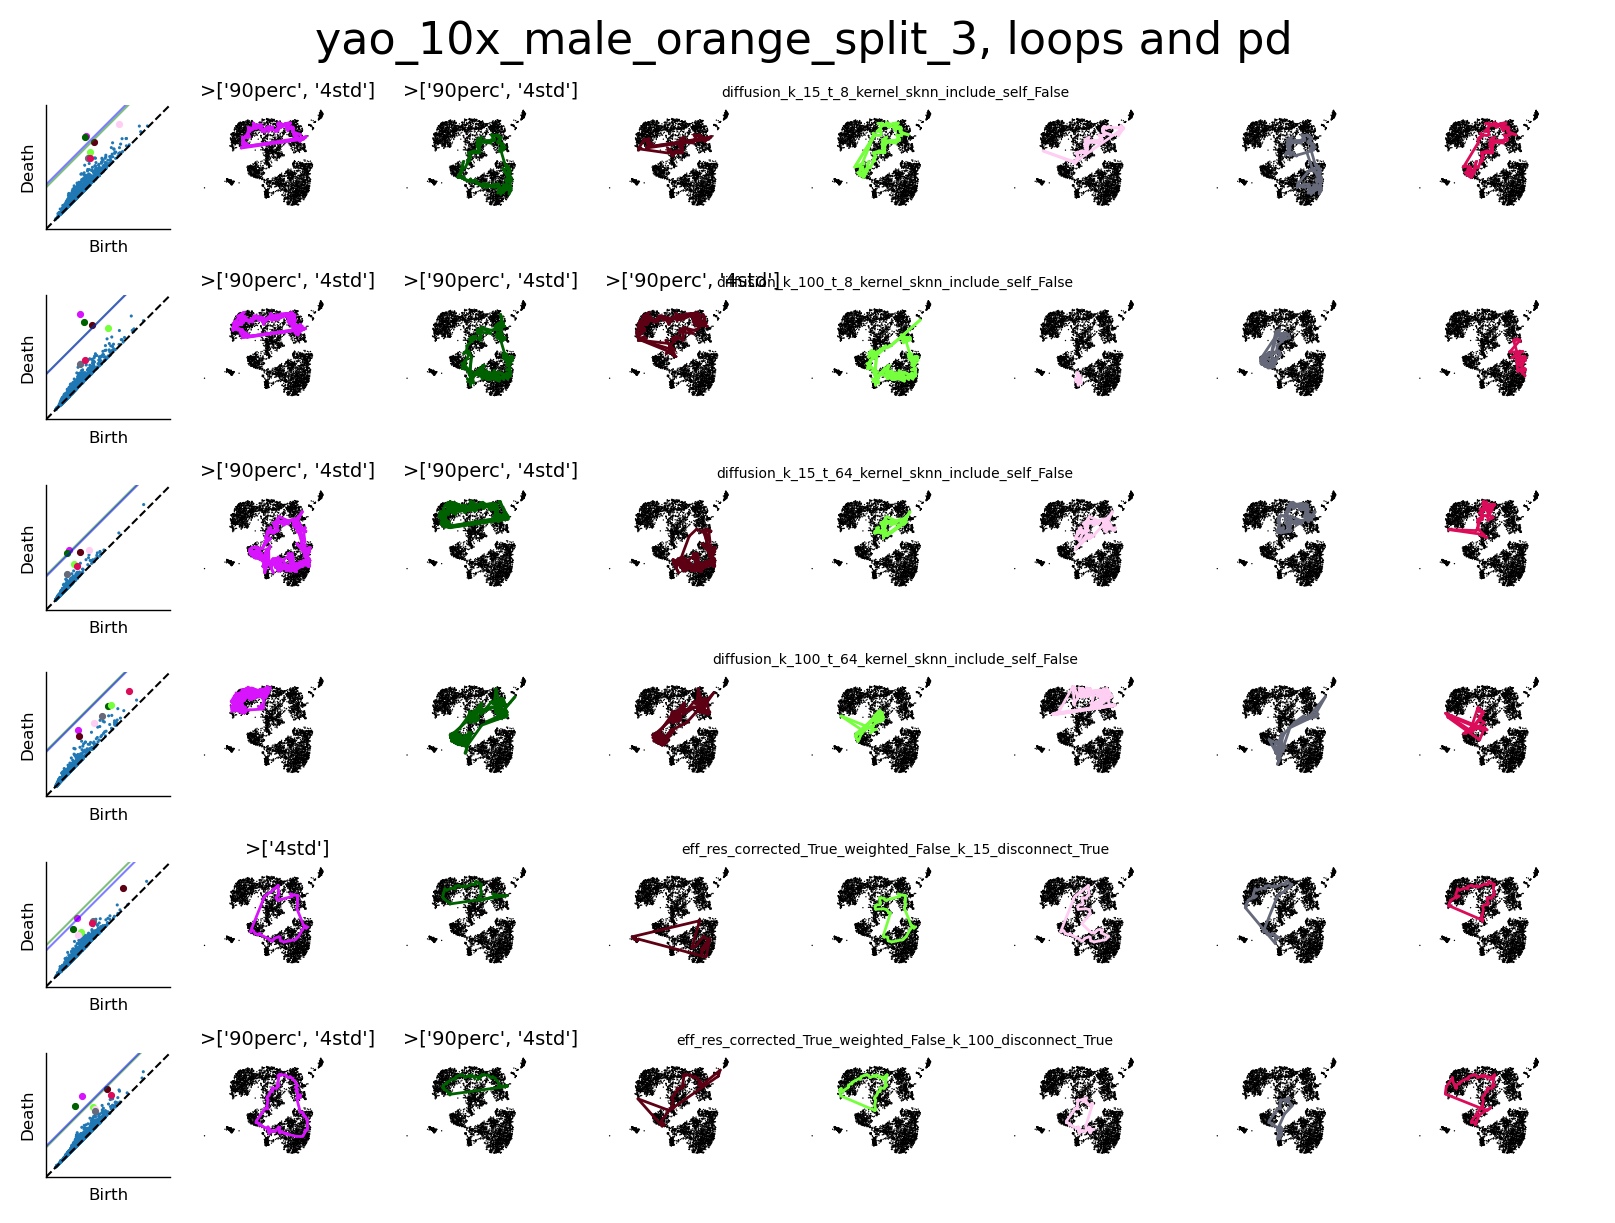

In [ ]:
batch_print_male(3)